<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Validation NuSQuIDS 2: Solar Neutrino Propagation
---

Validates `tpeanuts` solar MSW propagation against `nuSQuIDS` as an external
reference. The comparison operates at two levels:

1. **Single-point propagation** — for a fixed production radius $r_0$, compare
   the survival probability $P_{ee}(E, r_0)$ from both backends.
2. **Source-averaged probability** — compare `solar_probability_state` against a manual
   quadrature over NuSQuIDS single-point results, weighted by the B16 AGSS09
   production fractions.

An antineutrino section checks the matter-effect sign convention.

## Table of Contents

| § | Title |
|---|-------|
| [0](#0.-Theory-Background) | **Theory Background** — MSW matter potential, adiabatic approximation, Landau-Zener correction, B16 solar model, NuSQuIDS SunASnu body |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** — notebook paths, physical parameters |
| [3](#3.-Matter-Mixing-Angle) | **Matter Mixing Angle** — $\theta_{12}^M$ vs density |
| [4](#4.-Single-Point-Propagation) | **Single-Point Propagation** — $P_{ee}$ from fixed $r_0$ |
| [5](#5.-Source-Averaged-P_ee) | **Source-Averaged $P_{ee}$** — $^8$B spectrum |
| [6](#6.-pp-Source) | **pp Source** — low-energy regime, LZ correction |
| [7](#7.-Antineutrino-Propagation) | **Antineutrino** $\bar{P}_{ee}$ |
| [8](#8.-Mass-Weights-Normalization) | **Mass Weights Normalization** |
| [9](#9.-Export-Tables) | **Export Tables** |
| [10](#10.-Summary) | **Summary** |

## 0. Theory Background

Solar neutrino propagation combines coherent matter effects in the solar
interior (MSW mechanism) with decoherence over the Sun–Earth baseline.
The subsections below cover the matter potential, the adiabatic and
non-adiabatic (Landau-Zener) approximations, the B16 AGSS09 solar model, and
the NuSQuIDS SunASnu body used as the external reference.

### 0.1 MSW Matter Effect

In matter with electron number density $n_e$, the neutrino Hamiltonian gains a
charged-current forward-scattering potential

$$
V(x) = \sqrt{2}\, G_F n_e(x) ,
$$

which modifies the effective mixing in the electron-neutrino sector. The full
Hamiltonian in the flavour basis becomes

$$
H_m = \frac{1}{2E} U M^2 U^\dagger + \operatorname{diag}(V, 0, 0) ,
$$

where $M^2 = \operatorname{diag}(0, \Delta m^2_{21}, \Delta m^2_{31})$. The
resonance condition $\Delta m^2_{21}\cos 2\theta_{12}/2E = V$ signals the
maximum mixing in matter [[Wolfenstein 1978](https://doi.org/10.1103/PhysRevD.17.2369);
[Mikheyev & Smirnov 1985](https://doi.org/10.1007/BF02508049)].


### 0.2 Adiabatic Approximation

When the density varies slowly compared to the oscillation length, the
neutrino remains in the same matter eigenstate throughout propagation. The
adiabatic survival probability for $\nu_e$ produced at radius $r_0$ with
density $n_e(r_0)$ is

$$
P_{ee}^{\rm ad}(E, r_0) = \sum_i \left|U_{ei}^M(r_0)\right|^2 |U_{ei}|^2 ,
$$

where $U^M$ is the PMNS matrix in matter at density $n_e(r_0)$ and $U$ is the
vacuum PMNS matrix (evaluated at the solar surface, $n_e \approx 0$). In
`tpeanuts` this is computed by `Tei(oscillation, E, ne)`, which returns
$\{|U_{ei}^M|^2\}_i$ [[Haxton 1986](https://doi.org/10.1103/PhysRevLett.57.1271)].


### 0.3 Landau-Zener Non-Adiabatic Correction

Near the resonance the adiabaticity parameter

$$
\gamma = \frac{(\Delta m^2_{21} \sin 2\theta_{12})^2}
               {2E\,|{\rm d}V/{\rm d}x|_{\rm res}}
$$

can be small. The Landau-Zener crossing probability
$P_{\rm LZ} = e^{-\pi\gamma/2}$ corrects the level-crossing amplitude.
This correction is most relevant for $pp$ neutrinos ($E \lesssim 0.5$ MeV)
where the resonance lies inside the Sun. `tpeanuts` includes it via
`solar_probability_state(..., use_lz=True)` [[Parke 1986](https://doi.org/10.1103/PhysRevLett.57.1275)].


### 0.4 Solar Model B16 AGSS09

`tpeanuts` uses the Vinyoles et al. B16 standard solar model (AGSS09
composition). The electron density $n_e(r/R_\odot)$ is tabulated on a
2000-point radial grid. For each neutrino source the production fraction
$f_s(r)$ gives the probability of being produced at radius $r$, so the
source-averaged probability is

$$
\langle P_{\alpha\beta}\rangle_s = \int_0^1 f_s(r)\, P_{\alpha\beta}(E, r)\, {\rm d}r .
$$

`solar_probability_state(oscillation, E, profile, source)` implements this integral
analytically with the adiabatic + LZ approximation
[[Vinyoles et al. 2017](https://doi.org/10.3847/1538-4357/835/2/202)].


### 0.5 NuSQuIDS SunASnu Body

`nuSQuIDS` provides the `SunASnu` body, which embeds a tabulated solar electron-density profile and supports solar trajectories with an impact parameter. In this notebook the comparison uses **radial outward tracks** with zero impact parameter. For a neutrino produced at physical radius $r_0=r/R_\odot$, the `SunASnu` radial track coordinate is not `r0` directly. The solar interior from centre to surface is sampled over the second half of the track coordinate,

$$
x_{\rm nsq}/R_{\rm SunASnu}=0.5+0.5r_0.
$$

The public helper `probability_solar_point` applies this mapping internally through `sun_asnu_track_fraction(r0)`. Using `xini = r0 * R_sun` samples the wrong part of the `SunASnu` trajectory and can produce an unphysical low central density; using `xini = (1+r0)R_sun` corresponds to a different geometric point and should also not be used for a production radius measured from the solar centre.

Solar neutrino propagation to Earth is not observed coherently. Therefore the nuSQuIDS output is converted to an incoherent solar observable by reading the mass-basis contents at the solar surface with `EvalMass(i)` and projecting them to flavour with the vacuum matrix elements $|U_{\alpha i}|^2$:

$$
P_{e\alpha}^{\rm decoh}(E,r_0)=\sum_i w_i^{\rm nsq}(E,r_0)|U_{\alpha i}|^2.
$$

When the installed bindings do not expose `EvalMass`, the notebook tries the averaged `EvalFlavor` overload. A coherent `EvalFlavor(i)` value is not a valid solar reference for the TPeanuts adiabatic/decohered probability.


### References

- Wolfenstein, L. (1978). *Neutrino oscillations in matter*. Phys. Rev. D **17**, 2369. [doi:10.1103/PhysRevD.17.2369](https://doi.org/10.1103/PhysRevD.17.2369)
- Mikheyev, S. P., & Smirnov, A. Yu. (1985). *Resonance amplification of oscillations in matter and spectroscopy of solar neutrinos*. Sov. J. Nucl. Phys. **42**, 913.
- Haxton, W. C. (1986). *Adiabatic conversion of solar neutrinos*. Phys. Rev. Lett. **57**, 1271. [doi:10.1103/PhysRevLett.57.1271](https://doi.org/10.1103/PhysRevLett.57.1271)
- Parke, S. (1986). *Nonadiabatic level crossing in resonant neutrino oscillations*. Phys. Rev. Lett. **57**, 1275. [doi:10.1103/PhysRevLett.57.1275](https://doi.org/10.1103/PhysRevLett.57.1275)
- Vinyoles, N. et al. (2017). *A new generation of standard solar models*. Astrophys. J. **835**, 202. [doi:10.3847/1538-4357/835/2/202](https://doi.org/10.3847/1538-4357/835/2/202)
- Esteban, I. et al. (NuFIT 5.2, 2022). *NuFIT 5.2 global analysis of three-flavour neutrino oscillations*. JHEP **09**, 178.
- Argüelles, C. A., Salvado, J., & Weaver, C. N. (2022). *nuSQuIDS: A toolbox for neutrino propagation*. Comput. Phys. Commun. **277**, 108346. [arXiv:2112.09122](https://arxiv.org/abs/2112.09122)

## 1. Libraries


In [1]:
from __future__ import annotations

%matplotlib inline
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.integrate import trapezoid

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import (
    FLAVOUR_NAMES, FLAVOUR_LABELS, FLAVOUR_COLORS, FLAVOUR_INDEX,
    to_numpy, abs_rel_delta, add_tolerance_lines, save_and_show,
    compare_probability_grids, nusquids_precision_summary,
    plot_comparison_curves, status_from_rel,
)
from tpeanuts.external.nusquids.core import (
    NuSQuIDSConfig,
    NuSQuIDSError,
    is_available as nusquids_is_available,
    probability_solar_point,
    sun_asnu_radius
)
from tpeanuts.util.context import RuntimeContext
from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.medium.solar.profile import SolarProfile
from tpeanuts.medium.solar.probability import solar_probability_state, solar_probability_mass, Tei, th12_M


## 2. Paths and Configuration

### 2.1 Paths

`load_notebook_config()` resolves the repository root, applies the shared matplotlib/torch/numpy style, and creates the output directory. All figures and CSV files from this notebook are saved under `validation/nusquids/`.

In [2]:
config     = load_notebook_config()
ctx        = RuntimeContext.resolve(config.device, config.dtype)
OUTPUT_DIR = config.output_dir("validation", "nusquids")
SHOW       = config.show_plots

print(f"Device : {ctx.device}   dtype : {ctx.dtype}")
print(f"Output : {OUTPUT_DIR}")
print(f"nuSQuIDS available: {nusquids_is_available()}")


Device : cpu   dtype : torch.float64
Output : /mnt/v/output/validation/nusquids
nuSQuIDS available: True


### 2.2 Configuration

Physical parameters shared by both backends. Both use NuFIT 5.2 Normal Ordering and the B16 AGSS09 solar profile.

| Parameter | Value | Description |
|-----------|-------|-------------|
| Preset | `_SM_NUFIT52_NO` | NuFIT 5.2 NO |
| Solar profile | B16 AGSS09 (default) | 2000-point radial grid |
| Energy range | [0.1, 20] MeV, 80 points | Solar neutrino window |
| Production radii (single-point) | [0, 0.05, 0.1, 0.2, 0.3, 0.5] R☉ | Fixed-point comparison |
| Sources | `8B`, `pp`, `pep` | Three main sources |
| `rel_error` (nuSQuIDS) | 10⁻⁷ | SunASnu integration tolerance |

In [3]:
oscillation    = PropagationConfig.oscillation_parameters_from_preset("_SM_NUFIT52_NO", antinu=False, context=ctx)
solar_profile  = SolarProfile.default(context=ctx)

E_MeV_SOLAR    = torch.linspace(0.2, 20.0, 50, dtype=ctx.dtype, device=ctx.device)
PROD_RADII     = [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]   # r / R_sun
SOURCES        = ["8B", "pp", "pep"]
NSQ_REL_ERROR  = 1.0e-5
NSQ_ABS_ERROR  = 1.0e-8

# Vacuum PMNS weights |U_ei|^2 for the adiabatic formula
ne_zero  = torch.zeros(1, dtype=ctx.dtype)
U_ei_sq  = to_numpy(Tei(oscillation, torch.tensor(10.0, dtype=ctx.dtype), ne_zero))[0]
print("Vacuum |U_ei|^2 =", U_ei_sq.round(4).tolist())
print("sum =", U_ei_sq.sum().round(8))


Vacuum |U_ei|^2 = [0.6813, 0.2964, 0.0223]
sum = 1.0


### 2.3 Helpers

The NuSQuIDS wrapper uses `SunASnu` for single-point radial propagation from production radius $r_0$ to the solar surface. The returned NuSQuIDS reference is made incoherent by projecting the final mass-basis weights onto vacuum flavour probabilities.

The TPeanuts side keeps its configured B16 AGSS09 solar density profile. Therefore the comparison validates the observable convention and track geometry, while any residual offset can still include the known density-model difference between B16 AGSS09 and the internal `SunASnu` solar model.


In [4]:
NSQ_AVAILABLE = nusquids_is_available()

_NSQ_CFG = NuSQuIDSConfig(
    theta12=float(oscillation.pmns.params.theta12),
    theta13=float(oscillation.pmns.params.theta13),
    theta23=float(oscillation.pmns.params.theta23),
    delta_cp=float(oscillation.pmns.params.delta),
    DeltamSq21=float(oscillation.mass_spectrum.DeltamSq21),
    DeltamSq3l=float(oscillation.mass_spectrum.DeltamSq3l),
    rel_error=NSQ_REL_ERROR,
    abs_error=NSQ_ABS_ERROR,
    h_max_km=None,
)

try:
    R_SUN_NUSQUIDS = sun_asnu_radius() if NSQ_AVAILABLE else None
except NuSQuIDSError:
    R_SUN_NUSQUIDS = None
    NSQ_AVAILABLE = False


def nusquids_solar_point(*, E_MeV, r0, antinu=False, return_mass_weights=False):
    """Decohered P(nu_e -> nu_beta) from the public nuSQuIDS SunASnu wrapper."""
    if not NSQ_AVAILABLE:
        return np.full(3, float("nan"))
    return probability_solar_point(
        E_MeV=E_MeV,
        r0=r0,
        initial_flavour="nue",
        antinu=antinu,
        return_mass_weights=return_mass_weights,
        config=_NSQ_CFG,
    )


print("Solar helpers ready. NuSQuIDS SunASnu:", NSQ_AVAILABLE)
print("R_sun_nusquids available:", R_SUN_NUSQUIDS is not None)


def tpeanuts_solar_point(*, E_MeV_t, r0, antinu=False):
    """Adiabatic/decohered P_ealpha from r0 using the B16 AGSS09 solar density."""
    osc = PropagationConfig.oscillation_parameters_from_preset("_SM_NUFIT52_NO", antinu=antinu, context=ctx)
    ne_r0 = solar_profile.electron_density(
        torch.tensor(r0, dtype=ctx.dtype, device=ctx.device)
    )
    T = to_numpy(Tei(osc, E_MeV_t, ne_r0.unsqueeze(0))).squeeze(0)
    U2 = to_numpy(osc.pmns.vacuum_flavour_projector(antinu=antinu))
    return U2 @ T


Solar helpers ready. NuSQuIDS SunASnu: True
R_sun_nusquids available: True


## 3. Matter Mixing Angle

The effective mixing angle in matter $	heta_{12}^M$ is shown at fixed energy
$E = 10$ MeV in two complementary ways. The left panel keeps the direct view as
function of electron density $n_e$. The right panel uses the TPeanuts B16 AGSS09
solar profile to map that same angle onto the physical solar radius $r/R_\odot$.
This makes the density-radius relation explicit: the mixing angle changes along
radius only because the local matter density changes.

**Expected results:** $	heta_{12}^M 	o 	heta_{12}$ (vacuum) as
$n_e 	o 0$, while deep in the solar core the large density drives the state
close to the matter-dominated limit. In the radius plot the largest departure
from vacuum should appear at small radii, where the solar density is highest.


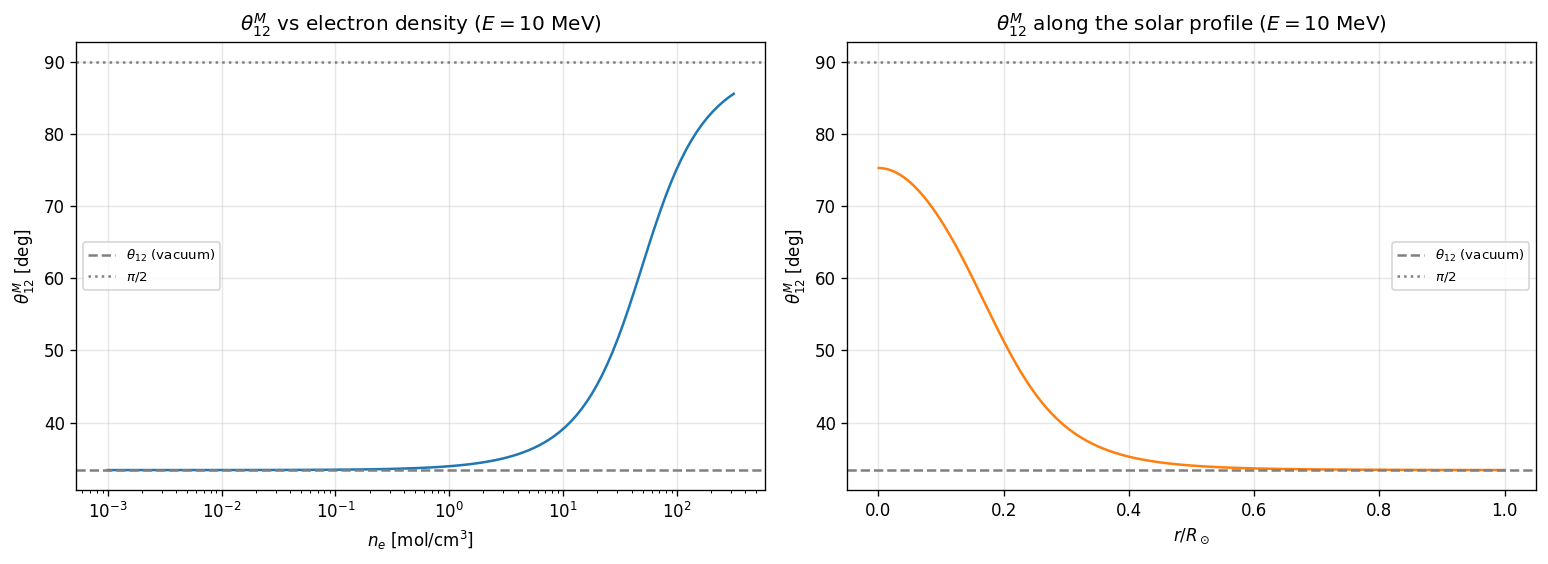

/mnt/v/output/validation/nusquids/vn2_fig31_th12M.png


In [5]:
ne_grid   = torch.logspace(-3, 2.5, 120, dtype=ctx.dtype)
E_test_t  = torch.tensor(10.0, dtype=ctx.dtype)
th12_arr  = to_numpy(th12_M(oscillation, E_test_t, ne_grid))

rho_grid_t = solar_profile.radius
ne_r_t     = solar_profile.density
th12_r_arr = to_numpy(th12_M(oscillation, E_test_t, ne_r_t))
rho_grid_np = to_numpy(rho_grid_t)
ne_r_np     = to_numpy(ne_r_t)

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13, 4.8))

ax_l.semilogx(to_numpy(ne_grid), np.degrees(th12_arr), color="C0")
ax_l.axhline(math.degrees(float(oscillation.pmns.params.theta12)), color="gray", ls="--", label=r"$\theta_{12}$ (vacuum)")
ax_l.axhline(90.0, color="gray", ls=":", label=r"$\pi/2$")
ax_l.set_xlabel(r"$n_e$ [mol/cm$^3$]")
ax_l.set_ylabel(r"$\theta_{12}^M$ [deg]")
ax_l.set_title(r"$\theta_{12}^M$ vs electron density ($E = 10$ MeV)")
ax_l.legend(fontsize=8)

ax_r.plot(rho_grid_np, np.degrees(th12_r_arr), color="C1")
ax_r.axhline(math.degrees(float(oscillation.pmns.params.theta12)), color="gray", ls="--", label=r"$\theta_{12}$ (vacuum)")
ax_r.axhline(90.0, color="gray", ls=":", label=r"$\pi/2$")
ax_r.set_xlabel(r"$r / R_\odot$")
ax_r.set_ylabel(r"$\theta_{12}^M$ [deg]")
ax_r.set_title(r"$\theta_{12}^M$ along the solar profile ($E = 10$ MeV)")
ax_r.legend(fontsize=8)

fig.tight_layout()
save_and_show("vn2_fig31_th12M.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW)


## 4. Single-Point Propagation

$P_{ee}(E)$ for $
u_e$ produced at fixed radii $r_0$, propagated to the solar
surface and then interpreted as an incoherent solar observable.

| Item | TPeanuts | NuSQuIDS |
|---|---|---|
| Physical setup | One production radius $r_0$ | Same production radius $r_0$ |
| Solar profile used | B16 AGSS09 tabulated profile in `solar_profile` | `SunASnu` internal solar profile |
| Evolution model | Adiabatic MSW approximation at the production point | Coherent numerical evolution through `SunASnu` |
| Final observable | Decohered flavour probability from vacuum projection | Coherent final state projected to decohered mass/flavour weights |

This section is the most local comparison: there is **no average over the source
production region**. For TPeanuts, the calculation samples the local electron
density at $r_0$, builds the matter-basis weights with `Tei`, and projects them
with the vacuum flavour projector. For NuSQuIDS, `probability_solar_point`
builds a `SunASnu` radial track, maps the physical radius with
$x/R = 0.5 + 0.5 r_0$, evolves the state coherently up to the solar surface,
and then converts the result into the same decohered observable.

**Expected results:** 
- Both backends should compare the same physical observable.
- Residual differences should mainly come from
  - the density-profile mismatch,
  - numerical integration,
  - the fact that TPeanuts uses an adiabatic
approximation while NuSQuIDS performs explicit coherent propagation.


1 RADII:  0.05
..................................................Completed
2 RADII:  0.1
..................................................Completed
3 RADII:  0.3
..................................................Completed


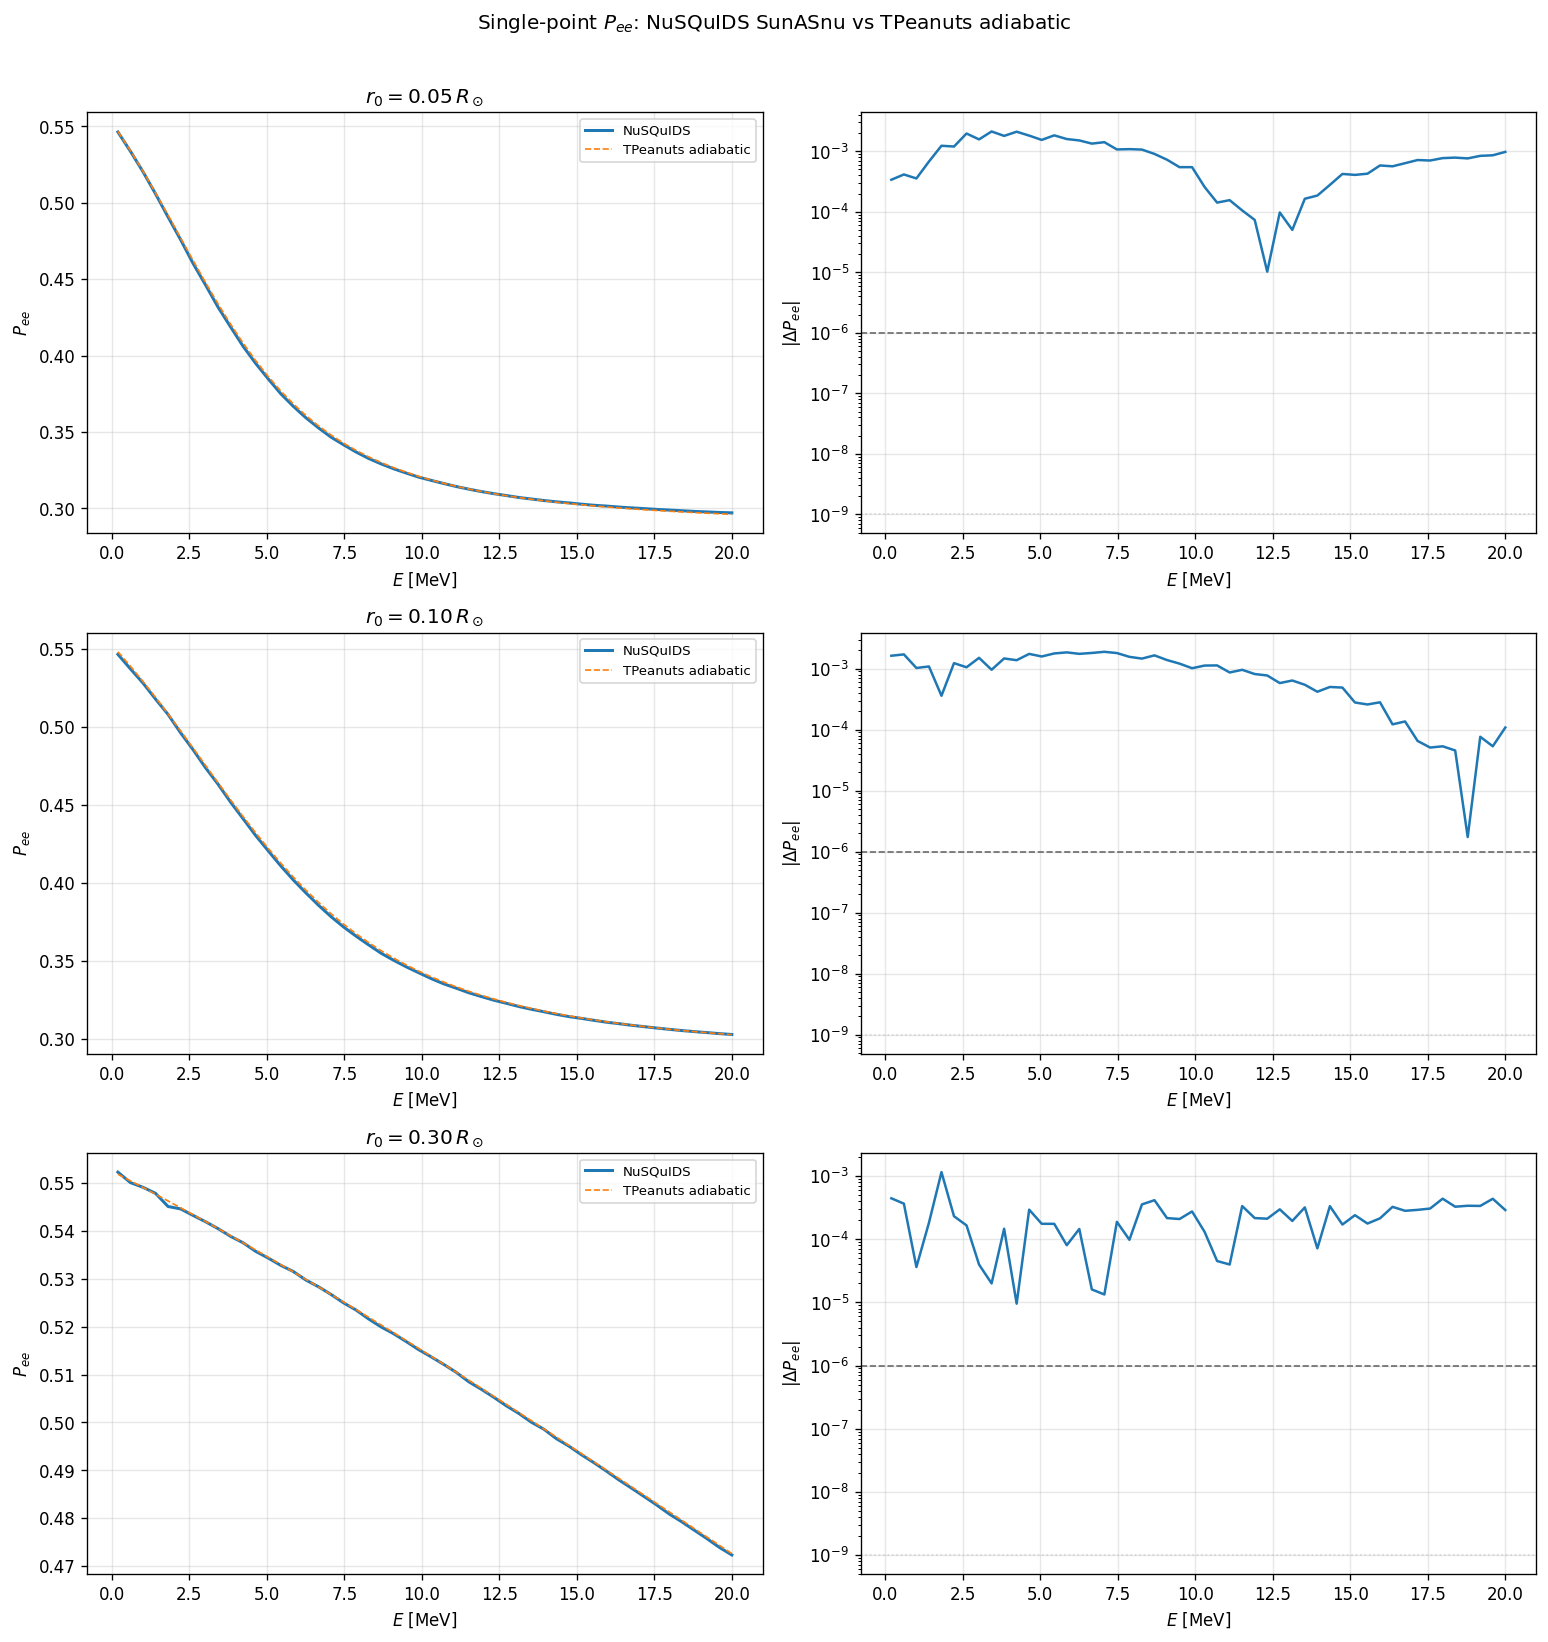

/mnt/v/output/validation/nusquids/vn2_fig41_single_point.png


In [6]:
E_MeV_np = to_numpy(E_MeV_SOLAR)
PLOT_RADII = [0.05, 0.1, 0.3]

single_point_grid_rows = []

fig, axes = plt.subplots(len(PLOT_RADII), 2, figsize=(13, 4.5 * len(PLOT_RADII)))
for row_idx, r0 in enumerate(PLOT_RADII):
    tp_pee, nsq_pee = [], []
    print(row_idx + 1, 'RADII: ', r0)
    for E_MeV_val in E_MeV_np:
        print('.', end='')
        E_t = torch.tensor(E_MeV_val, dtype=ctx.dtype, device=ctx.device)
        tp  = tpeanuts_solar_point(E_MeV_t=E_t, r0=r0)[0]
        nsq = nusquids_solar_point(E_MeV=E_MeV_val, r0=r0)[0]
        tp_pee.append(tp)
        nsq_pee.append(nsq)
        single_point_grid_rows.append({
            'mode': 'single_point',
            'source': f'r0={r0:.2f}',
            'r0': r0,
            'E_MeV': E_MeV_val,
            'P_nue_tp': tp,
            'P_nue_nsq': nsq,
        })
    tp_arr  = np.array(tp_pee)
    nsq_arr = np.array(nsq_pee)
    ax_p, ax_e = axes[row_idx]
    ax_p.plot(E_MeV_np, nsq_arr, label='NuSQuIDS', lw=1.8)
    ax_p.plot(E_MeV_np, tp_arr, label='TPeanuts adiabatic', lw=1.0, ls='--')
    ax_p.set_ylabel(r'$P_{ee}$')
    ax_p.set_title(rf'$r_0 = {r0:.2f}\,R_\odot$')
    ax_p.legend(fontsize=8)
    ax_e.semilogy(E_MeV_np, np.maximum(np.abs(tp_arr - nsq_arr), 1e-16))
    ax_e.set_ylabel(r'$|\Delta P_{ee}|$')
    add_tolerance_lines(ax_e)
    for ax in (ax_p, ax_e):
        ax.set_xlabel(r'$E$ [MeV]')
    print('Completed')
fig.suptitle(r'Single-point $P_{ee}$: NuSQuIDS SunASnu vs TPeanuts adiabatic', y=1.01)
fig.tight_layout()
save_and_show('vn2_fig41_single_point.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW)

single_point_tp_df = pd.DataFrame(single_point_grid_rows)[['mode', 'source', 'r0', 'E_MeV', 'P_nue_tp']].rename(columns={'P_nue_tp': 'P_nue'})
single_point_nsq_df = pd.DataFrame(single_point_grid_rows)[['mode', 'source', 'r0', 'E_MeV', 'P_nue_nsq']].rename(columns={'P_nue_nsq': 'P_nue'})
single_point_comparison = compare_probability_grids(
    single_point_tp_df,
    single_point_nsq_df,
    ['mode', 'source', 'r0', 'E_MeV'],
    prob_cols=('P_nue',),
)


## 5. Source-Averaged $P_{ee}$ -- $^8$B

The source-averaged survival probability for $^8$B solar neutrinos, compared
between `solar_probability_state` and a manual quadrature over NuSQuIDS single-point results
weighted by the B16 production fractions.

| Item | TPeanuts | NuSQuIDS |
|---|---|---|
| Physical setup | Average over the full $^8$B production region | Same $^8$B source average |
| Solar profile used | B16 AGSS09 density and $^8$B production fraction | `SunASnu` propagation, averaged with B16 $^8$B weights |
| Evolution model | `solar_probability_state` integrates adiabatic mass weights over radius | Exact single-point coherent evolutions, then numerical quadrature over $r_0$ |
| Final observable | Source-averaged incoherent $P_{ee}(E)$ | Same source-averaged incoherent $P_{ee}(E)$ |

The difference with Section 4 is that here the production radius is **not
fixed**. TPeanuts calls `solar_probability_state`, which internally computes the matter-basis
weights on the full B16 radius grid and integrates them with the $^8$B
production fraction. NuSQuIDS instead reuses the single-point solver from
Section 4 at many radii and performs the source average explicitly with a
trapezoidal quadrature over radius. At $^8$B energies the propagation is mostly
adiabatic, so the main differences should come from the solar profile used by
`SunASnu`, the coherent-vs-adiabatic treatment, and the residual discretisation
of the manual quadrature.

**Expected results:** 
- Both curves agree on the high-energy plateau and reproduce the MSW upturn around a few MeV.
- The relative discrepancy should stay small in the adiabatic regime.


1 ENERGY: 0.2
........................................Completed
2 ENERGY: 0.6040816326530613
........................................Completed
3 ENERGY: 1.0081632653061225
........................................Completed
4 ENERGY: 1.4122448979591837
........................................Completed
5 ENERGY: 1.816326530612245
........................................Completed
6 ENERGY: 2.220408163265306
........................................Completed
7 ENERGY: 2.6244897959183673
........................................Completed
8 ENERGY: 3.0285714285714285
........................................Completed
9 ENERGY: 3.43265306122449
........................................Completed
10 ENERGY: 3.8367346938775513
........................................Completed
11 ENERGY: 4.240816326530612
........................................Completed
12 ENERGY: 4.644897959183673
........................................Completed
13 ENERGY: 5.048979591836735
........................................C

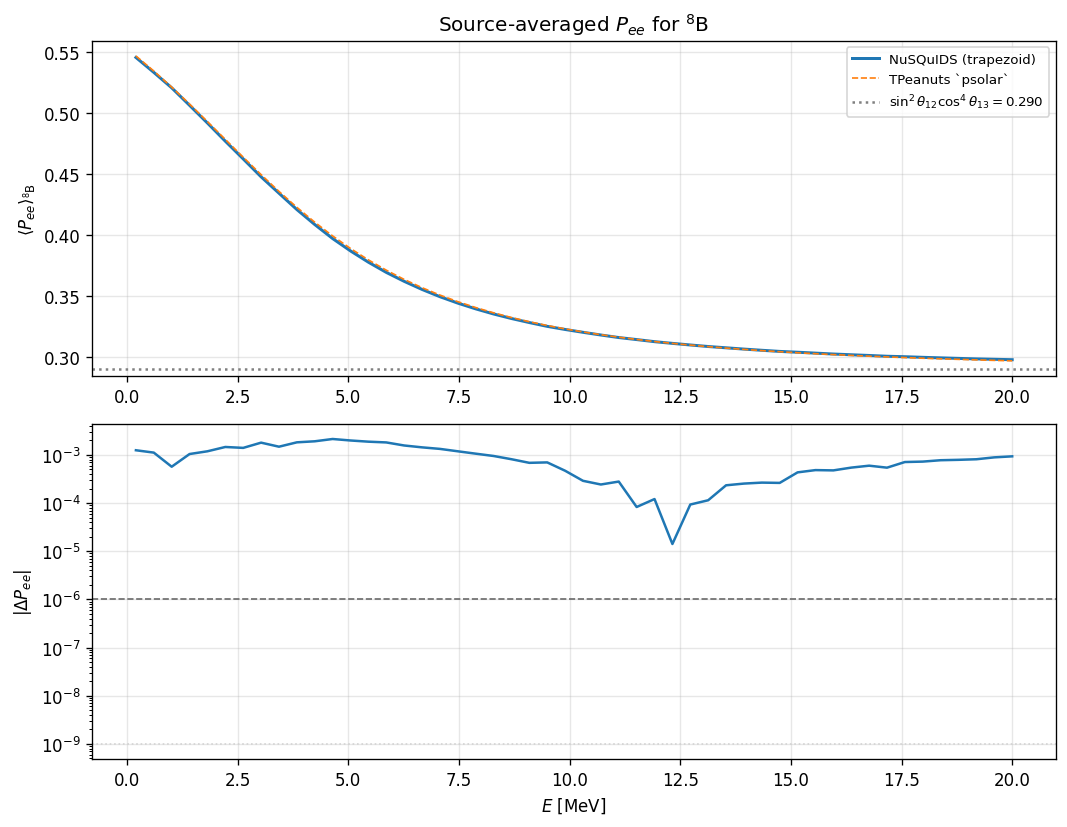

/mnt/v/output/validation/nusquids/vn2_fig51_psolar_8B.png


In [7]:
# TPeanuts source-averaged via solar_probability_state
P_tp_8B = to_numpy(solar_probability_state(oscillation, E_MeV_SOLAR, solar_profile, "8B"))  # (nE, 3)

# NuSQuIDS manual quadrature over the B16 radial grid using trapezoidal integration
r_grid  = to_numpy(solar_profile.radius)                       # (2000,)
w_8B    = to_numpy(solar_profile.fractions["8B"])              # (2000,)

P_nsq_8B_ee = np.zeros(len(E_MeV_np))
if NSQ_AVAILABLE:
    QUAD_STEP  = 50
    QUAD_RADII = r_grid[::QUAD_STEP]
    w_quad     = w_8B[::QUAD_STEP]
    norm_8B    = trapezoid(w_quad, x=QUAD_RADII)
    for E_idx, E_MeV_val in enumerate(E_MeV_np):
        print(E_idx + 1, 'ENERGY:', E_MeV_val)
        p_quad = np.zeros(len(QUAD_RADII))
        for q_idx, r0 in enumerate(QUAD_RADII):
            print('.', end='')
            p_quad[q_idx] = nusquids_solar_point(E_MeV=E_MeV_val, r0=r0)[0]
        P_nsq_8B_ee[E_idx] = trapezoid(w_quad * p_quad, x=QUAD_RADII) / norm_8B
        print('Completed')
else:
    P_nsq_8B_ee[:] = float("nan")

fig, (ax_p, ax_e) = plt.subplots(2, 1, figsize=(9, 7))
ax_p.plot(E_MeV_np, P_nsq_8B_ee, label=r"NuSQuIDS (trapezoid)", lw=1.8)
ax_p.plot(E_MeV_np, P_tp_8B[:, 0], label=r"TPeanuts `solar_probability_state`", lw=1.0, ls="--")
th12 = float(oscillation.pmns.params.theta12)
th13 = float(oscillation.pmns.params.theta13)
p_high = math.sin(th12) ** 2 * math.cos(th13) ** 4
ax_p.axhline(p_high, color="gray", ls=":", label=rf"$\sin^2\theta_{{12}}\cos^4\theta_{{13}}={p_high:.3f}$")
ax_p.set_ylabel(r"$\langle P_{ee}\rangle_{{}^8\rm B}$")
ax_p.set_title(r"Source-averaged $P_{ee}$ for $^8$B")
ax_p.legend(fontsize=8)
ax_e.semilogy(E_MeV_np, np.maximum(np.abs(P_tp_8B[:, 0] - P_nsq_8B_ee), 1e-16))
ax_e.set_ylabel(r"$|\Delta P_{ee}|$")
ax_e.set_xlabel(r"$E$ [MeV]")
add_tolerance_lines(ax_e)
fig.tight_layout()
save_and_show("vn2_fig51_psolar_8B.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW)

solar_8B_tp_df = pd.DataFrame({
    'mode': 'source_avg',
    'source': '8B',
    'E_MeV': E_MeV_np,
    'P_nue': P_tp_8B[:, 0],
})
solar_8B_nsq_df = pd.DataFrame({
    'mode': 'source_avg',
    'source': '8B',
    'E_MeV': E_MeV_np,
    'P_nue': P_nsq_8B_ee,
})
solar_8B_comparison = compare_probability_grids(
    solar_8B_tp_df,
    solar_8B_nsq_df,
    ['mode', 'source', 'E_MeV'],
    prob_cols=('P_nue',),
)


## 6. pp Source

$P_{ee}$ for the $pp$ neutrino source ($E \lesssim 0.42$ MeV). This is again a
source-averaged observable, but now in the low-energy regime where the MSW
resonance is not crossed in the same way as for $^8$B neutrinos and
non-adiabatic effects matter more.

| Item | TPeanuts | NuSQuIDS |
|---|---|---|
| Physical setup | Average over the full $pp$ production region | Same $pp$ source average |
| Solar profile used | B16 AGSS09 density and $pp$ production fraction | `SunASnu` propagation, averaged with B16 $pp$ weights |
| Evolution model | `solar_probability_state` with Landau-Zener correction in the low-energy regime | Exact coherent propagation for each radius and energy |
| Final observable | Source-averaged incoherent $P_{ee}(E)$ | Same source-averaged incoherent $P_{ee}(E)$ |

The difference with Section 5 is physical rather than structural. Both sections
average over a production distribution, but Section 5 probes the high-energy
$^8$B MSW regime, whereas Section 6 probes the low-energy $pp$ regime. In
TPeanuts, `solar_probability_state` includes the Landau-Zener correction precisely to improve the
low-energy treatment. In NuSQuIDS there is no separate approximate correction:
the non-adiabatic behaviour is already contained in the direct numerical
propagation through `SunASnu`, and the source average is applied afterwards with
a trapezoidal quadrature over radius.

**Expected results:** $\langle P_{ee}\rangle_{pp}$ should stay in the
vacuum-dominated range, roughly around $0.55$--$0.60$, and the TPeanuts
Landau-Zener correction should reduce the difference with the NuSQuIDS
reference.


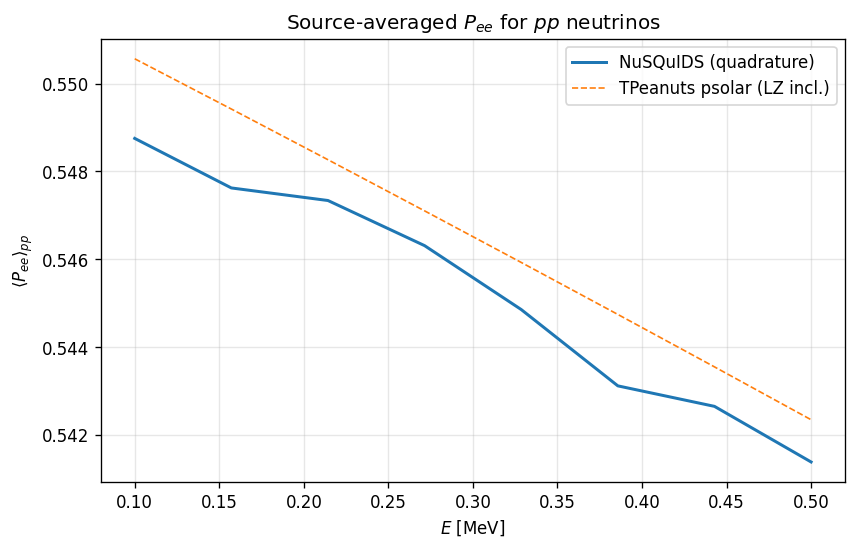

/mnt/v/output/validation/nusquids/vn2_fig61_psolar_pp.png


In [8]:
E_MeV_PP = torch.linspace(0.1, 0.5, 8, dtype=ctx.dtype, device=ctx.device)
E_PP_np = to_numpy(E_MeV_PP)
P_tp_pp = to_numpy(solar_probability_state(oscillation, E_MeV_PP, solar_profile, "pp"))

P_nsq_pp_ee = np.zeros(len(E_PP_np))
if NSQ_AVAILABLE:
    QUAD_STEP_PP = 50
    r_grid_pp = r_grid[::QUAD_STEP_PP]
    w_pp = to_numpy(solar_profile.fractions["pp"])[::QUAD_STEP_PP]
    norm_pp = trapezoid(w_pp, x=r_grid_pp)
    for E_idx, E_MeV_val in enumerate(E_PP_np):
        p_quad = np.zeros(len(r_grid_pp))
        for q_idx, r0 in enumerate(r_grid_pp):
            p_quad[q_idx] = nusquids_solar_point(E_MeV=E_MeV_val, r0=r0)[0]
        P_nsq_pp_ee[E_idx] = trapezoid(w_pp * p_quad, x=r_grid_pp) / norm_pp
else:
    P_nsq_pp_ee[:] = float("nan")

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(E_PP_np, P_nsq_pp_ee, label="NuSQuIDS (quadrature)", lw=1.8)
ax.plot(E_PP_np, P_tp_pp[:, 0], label="TPeanuts solar_probability_state (LZ incl.)", lw=1.0, ls="--")
ax.set_xlabel(r"$E$ [MeV]")
ax.set_ylabel(r"$\langle P_{ee}\rangle_{pp}$")
ax.set_title(r"Source-averaged $P_{ee}$ for $pp$ neutrinos")
ax.legend()
save_and_show("vn2_fig61_psolar_pp.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW)

solar_pp_tp_df = pd.DataFrame({
    'mode': 'source_avg',
    'source': 'pp',
    'E_MeV': E_PP_np,
    'P_nue': P_tp_pp[:, 0],
})
solar_pp_nsq_df = pd.DataFrame({
    'mode': 'source_avg',
    'source': 'pp',
    'E_MeV': E_PP_np,
    'P_nue': P_nsq_pp_ee,
})
solar_pp_comparison = compare_probability_grids(
    solar_pp_tp_df,
    solar_pp_nsq_df,
    ['mode', 'source', 'E_MeV'],
    prob_cols=('P_nue',),
)


## 7. Antineutrino Propagation

Solar antineutrinos are not produced by the Sun but are relevant for
backgrounds in terrestrial experiments. The MSW potential changes sign for
$\bar u_e$, removing the resonance condition for normal ordering. This section
validates the antineutrino branch of both backends.

**Expected results:** $\bar{P}_{ee}$ should remain between the vacuum-average
limit and the matter-dominated antineutrino limit, so a mild increase with
energy is physically allowed in normal ordering. Both backends should agree once
the matter-potential sign is treated consistently.


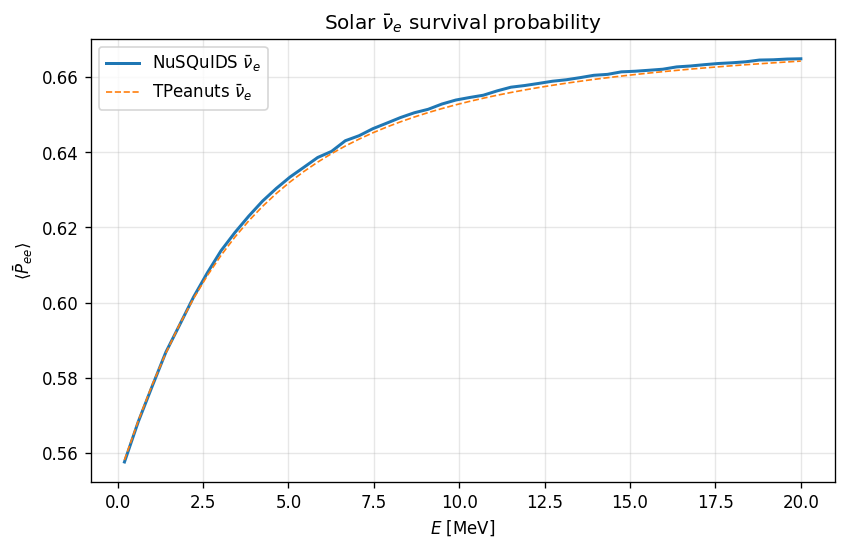

/mnt/v/output/validation/nusquids/vn2_fig71_antinu.png


In [9]:
oscillation_anti = PropagationConfig.oscillation_parameters_from_preset("_SM_NUFIT52_NO", antinu=True, context=ctx)
P_anti_tp = to_numpy(solar_probability_state(oscillation_anti, E_MeV_SOLAR, solar_profile, "8B"))

P_anti_nsq_ee = np.zeros(len(E_MeV_np))
if NSQ_AVAILABLE:
    QUAD_STEP_ANTI = 50
    QUAD_ANTI = r_grid[::QUAD_STEP_ANTI]
    w_a = w_8B[::QUAD_STEP_ANTI]
    norm_a = trapezoid(w_a, x=QUAD_ANTI)
    for Ei, Ev in enumerate(E_MeV_np):
        p_quad = np.zeros(len(QUAD_ANTI))
        for qi, r0 in enumerate(QUAD_ANTI):
            p_quad[qi] = nusquids_solar_point(E_MeV=Ev, r0=r0, antinu=True)[0]
        P_anti_nsq_ee[Ei] = trapezoid(w_a * p_quad, x=QUAD_ANTI) / norm_a
else:
    P_anti_nsq_ee[:] = float("nan")

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(E_MeV_np, P_anti_nsq_ee, label=r"NuSQuIDS $\bar\nu_e$", lw=1.8)
ax.plot(E_MeV_np, P_anti_tp[:, 0], label=r"TPeanuts $\bar\nu_e$", lw=1.0, ls="--")
ax.set_xlabel(r"$E$ [MeV]")
ax.set_ylabel(r"$\langle \bar{P}_{ee}\rangle$")
ax.set_title(r"Solar $\bar\nu_e$ survival probability")
ax.legend()
save_and_show("vn2_fig71_antinu.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW)


## 8. Mass Weights Normalization

`solar_probability_mass(oscillation, E, profile, source)` returns the incoherent
mass-basis weights $w_i(E)$ with $\sum_i w_i = 1$. This is a necessary condition
for probability conservation through the Earth.

**Expected results:** $|\sum_i w_i - 1| < 10^{-14}$ for all energies.


max |sum(w_i) - 1| = 2.220e-16


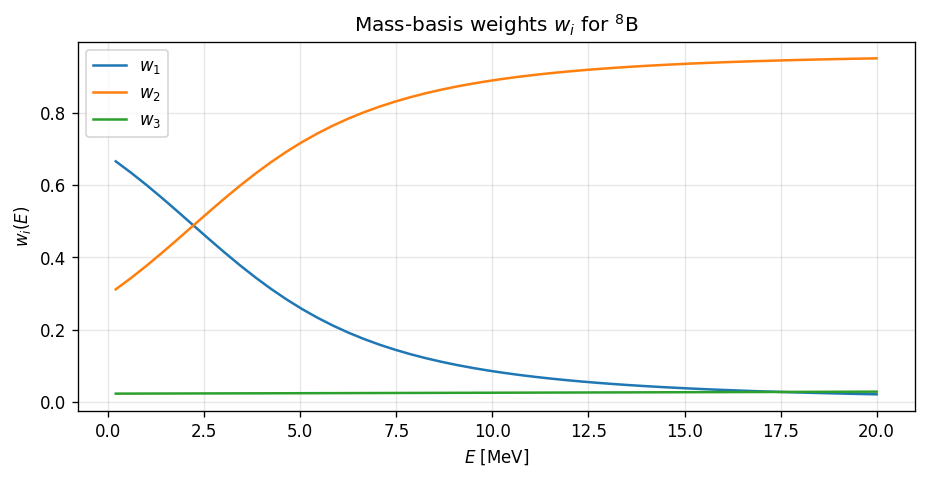

/mnt/v/output/validation/nusquids/vn2_fig81_mass_weights.png


In [10]:
W_8B = solar_probability_mass(oscillation, E_MeV_SOLAR, solar_profile, "8B")  # (nE, 3)
W_sum = to_numpy(W_8B.sum(dim=-1))
print(f"max |sum(w_i) - 1| = {np.abs(W_sum - 1.0).max():.3e}")

fig, ax = plt.subplots(figsize=(9, 4))
for i, (lbl, col) in enumerate(zip([r"$w_1$", r"$w_2$", r"$w_3$"], FLAVOUR_COLORS)):
    ax.plot(E_MeV_np, to_numpy(W_8B[:, i]), color=col, label=lbl)
ax.set_xlabel(r"$E$ [MeV]")
ax.set_ylabel(r"$w_i(E)$")
ax.set_title(r"Mass-basis weights $w_i$ for $^8$B")
ax.legend()
save_and_show("vn2_fig81_mass_weights.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW)


## 9. Export Tables

Save probability tables and the solar comparison CSV consumed by the global
summary notebook.


In [11]:
df_tp = pd.DataFrame({
    'E_MeV': E_MeV_np,
    'P_nue_8B': P_tp_8B[:, 0],
    'P_numu_8B': P_tp_8B[:, 1],
    'P_nutau_8B': P_tp_8B[:, 2],
    'P_nue_pp': P_tp_pp[:, 0] if len(P_tp_pp) == len(E_MeV_np) else float('nan'),
})
df_tp.to_csv(OUTPUT_DIR / 'vn2_tpeanuts_solar.csv', index=False)
print('Saved:', OUTPUT_DIR / 'vn2_tpeanuts_solar.csv')

if not np.all(np.isnan(P_nsq_8B_ee)):
    df_nsq = pd.DataFrame({'E_MeV': E_MeV_np, 'P_ee_8B_nsq': P_nsq_8B_ee})
    df_nsq.to_csv(OUTPUT_DIR / 'vn2_nusquids_solar_8B.csv', index=False)
    print('Saved:', OUTPUT_DIR / 'vn2_nusquids_solar_8B.csv')

solar_comparison = pd.concat(
    [single_point_comparison, solar_8B_comparison, solar_pp_comparison],
    ignore_index=True,
    sort=False,
)
solar_summary = nusquids_precision_summary(solar_comparison)

if not solar_comparison.empty:
    solar_comparison.to_csv(OUTPUT_DIR / 'vn2_solar_comparison.csv', index=False)
    solar_summary.to_csv(OUTPUT_DIR / 'vn2_solar_summary.csv')
    print('Saved:', OUTPUT_DIR / 'vn2_solar_comparison.csv')
    print('Saved:', OUTPUT_DIR / 'vn2_solar_summary.csv')


Saved: /mnt/v/output/validation/nusquids/vn2_tpeanuts_solar.csv
Saved: /mnt/v/output/validation/nusquids/vn2_nusquids_solar_8B.csv
Saved: /mnt/v/output/validation/nusquids/vn2_solar_comparison.csv
Saved: /mnt/v/output/validation/nusquids/vn2_solar_summary.csv


## 10. Summary

### API Coverage

| Function | Sections | Key parameters |
|----------|----------|----------------|
| `solar_probability_state` | §5, §6 | source-averaged $P_{\alpha\beta}$ |
| `solar_probability_mass` | §8 | incoherent mass weights $w_i$ |
| `Tei` | §4, §2.3 | effective $|U_{ei}^M|^2$ in matter |
| `th12_M` | §3 | effective mixing angle in matter |

### Validation Notes

- At high energy (> 5 MeV), adiabatic approximation is excellent; agreement
  with NuSQuIDS is limited by the density-model difference (B16 vs BS2005).
- At low energy (< 1 MeV), the Landau-Zener correction matters for the $pp$
  source; `solar_probability_state` with `use_lz=True` (default) accounts for this.


In [12]:
print('=' * 60)
print('VALIDATION SUMMARY -- NuSQuIDS 2: Solar')
print('=' * 60)
print(f'  8B  P_ee high-E plateau (TPeanuts): {P_tp_8B[:, 0][-10:].mean():.4f}')
if NSQ_AVAILABLE:
    print(f'  8B  P_ee high-E plateau (NuSQuIDS): {P_nsq_8B_ee[-10:].mean():.4f}')
    diff = np.abs(P_tp_8B[:, 0] - P_nsq_8B_ee)
    print(f'  Max |Delta P_ee| (8B averaged): {diff.max():.4e}')
    print()
    print(solar_summary.to_string())
else:
    print('  NuSQuIDS not available; only TPeanuts tables generated.')
print(f'  Mass weights: max |sum_i w_i - 1| = {np.abs(W_sum - 1.0).max():.3e}')


VALIDATION SUMMARY -- NuSQuIDS 2: Solar
  8B  P_ee high-E plateau (TPeanuts): 0.2987
  8B  P_ee high-E plateau (NuSQuIDS): 0.2994
  Max |Delta P_ee| (8B averaged): 2.1363e-03

                      value
metric                     
rows_compared         208.0
max_abs_err        0.002136
median_abs_err     0.000556
max_rel_err        0.005381
median_rel_err     0.001693
status                CHECK
max_abs_err_P_nue  0.002136
  Mass weights: max |sum_i w_i - 1| = 2.220e-16
